# EMF

Enter number of parallel paths A (for Lap: A=P, for Wave: A=2): 3

DC GENERATOR EMF & WINDING SIMULATOR
Poles (P)          = 4
Flux/pole (φ)      = 0.07 Wb
Conductors (Z)     = 440
Speed (N)          = 900 rpm
Parallel paths (A) = 3  →  Custom (A=3) winding
Pole Pitch         = 110.0 conductors/pole
Generated EMF (E)  = 616.00 Volts


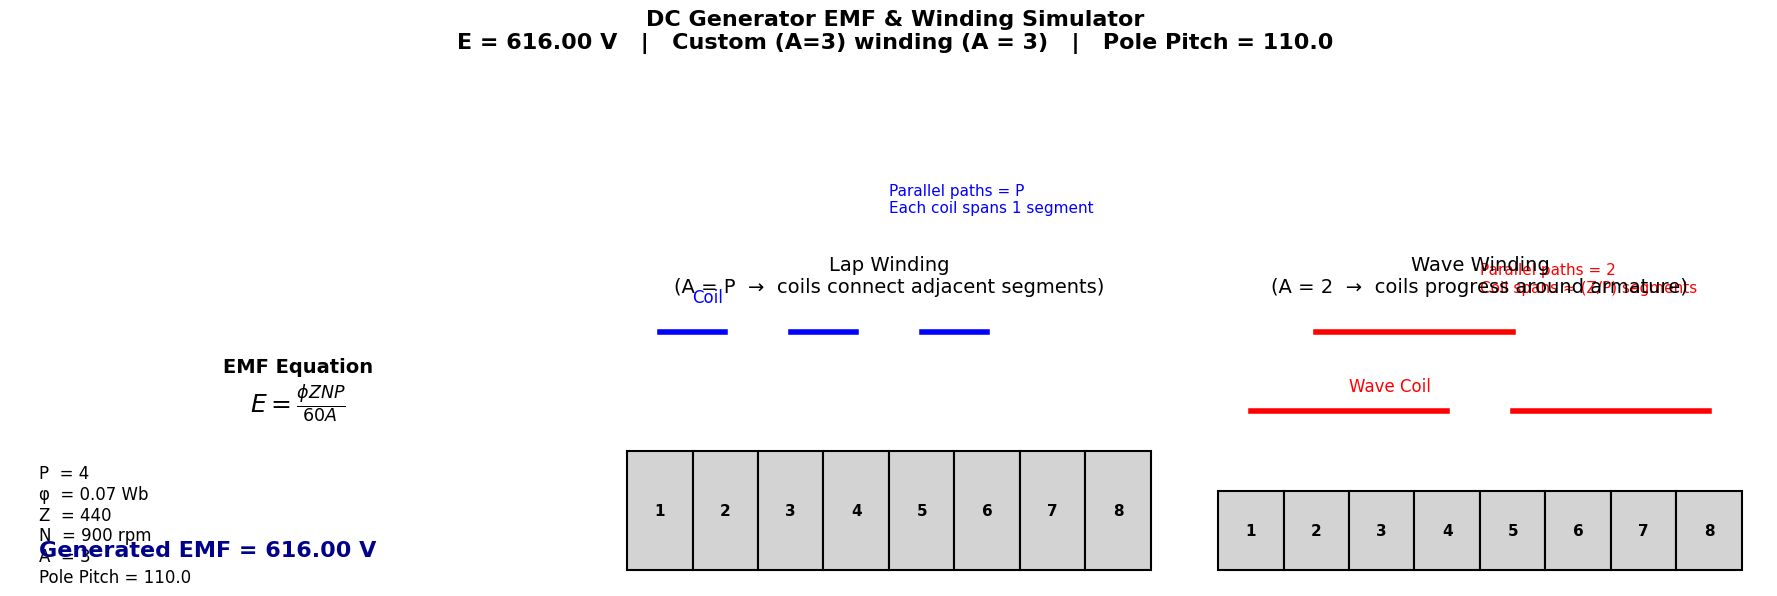

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ====================== USER INPUTS (Change these easily) ======================
P = 4          # Number of poles
phi = 0.07     # Flux per pole (Wb)   ← example from your notes
Z = 440        # Total number of armature conductors
N = 900        # Speed (rpm)          ← example from your notes

# Enter A (parallel paths) → auto-detect winding type
A = int(input("Enter number of parallel paths A (for Lap: A=P, for Wave: A=2): "))

if A == P:
    winding_type = "Lap"
elif A == 2:
    winding_type = "Wave"
else:
    winding_type = "Custom (A={})".format(A)

##------------------- calculation --------------------------
pole_pitch = Z / P
E = (phi * Z * N * P) / (60 * A)

print("\n" + "="*60)
print("DC GENERATOR EMF & WINDING SIMULATOR")
print("="*60)
print(f"Poles (P)          = {P}")
print(f"Flux/pole (φ)      = {phi} Wb")
print(f"Conductors (Z)     = {Z}")
print(f"Speed (N)          = {N} rpm")
print(f"Parallel paths (A) = {A}  →  {winding_type} winding")
print(f"Pole Pitch         = {pole_pitch:.1f} conductors/pole")
print(f"Generated EMF (E)  = {E:.2f} Volts")
print("="*60)

#------------------------- VISUAL -------------------------
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"DC Generator EMF & Winding Simulator\n"
             f"E = {E:.2f} V   |   {winding_type} winding (A = {A})   |   Pole Pitch = {pole_pitch:.1f}",
             fontsize=16, fontweight='bold')

axs[0].axis('off')
axs[0].text(0.5, 0.8, "EMF Equation", fontsize=14, ha='center', fontweight='bold')
axs[0].text(0.5, 0.65, r"$E = \frac{\phi Z N P}{60 A}$", fontsize=18, ha='center')
axs[0].text(0.05, 0.45, f"P  = {P}\nφ  = {phi} Wb\nZ  = {Z}\nN  = {N} rpm\nA  = {A}\nPole Pitch = {pole_pitch:.1f}",
            fontsize=12, va='top')
axs[0].text(0.05, 0.1, f"Generated EMF = {E:.2f} V", fontsize=16, color='darkblue', fontweight='bold')

# ------------------- Middle: LAP Winding Diagram -------------------
axs[1].set_title("Lap Winding\n(A = P  →  coils connect adjacent segments)", fontsize=14, pad=20)
axs[1].axis('off')

num_seg = 8  # Representative commutator segments for clear visualization
for i in range(num_seg):
    axs[1].add_patch(Rectangle((i, 0), 1, 0.6, edgecolor='black', facecolor='lightgray', linewidth=1.5))
    axs[1].text(i + 0.5, 0.3, str(i+1), ha='center', va='center', fontsize=11, fontweight='bold')

# Lap coils (adjacent segments)
axs[1].plot([0.5, 1.5], [1.2, 1.2], 'b-', lw=4)   # Coil 1-2
axs[1].text(1.0, 1.35, 'Coil', color='blue', fontsize=12)
axs[1].plot([2.5, 3.5], [1.2, 1.2], 'b-', lw=4)   # Coil 3-4
axs[1].plot([4.5, 5.5], [1.2, 1.2], 'b-', lw=4)

axs[1].text(4, 1.8, "Parallel paths = P\nEach coil spans 1 segment", fontsize=11, color='blue')

axs[2].set_title("Wave Winding\n(A = 2  →  coils progress around armature)", fontsize=14, pad=20)
axs[2].axis('off')

for i in range(num_seg):
    axs[2].add_patch(Rectangle((i, 0), 1, 0.6, edgecolor='black', facecolor='lightgray', linewidth=1.5))
    axs[2].text(i + 0.5, 0.3, str(i+1), ha='center', va='center', fontsize=11, fontweight='bold')

# Wave coils ( it shows progressive connection)
axs[2].plot([0.5, 3.5], [1.2, 1.2], 'r-', lw=4)   # Typical wave step
axs[2].text(2.0, 1.35, 'Wave Coil', color='red', fontsize=12)
axs[2].plot([1.5, 4.5], [1.8, 1.8], 'r-', lw=4)
axs[2].plot([4.5, 7.5], [1.2, 1.2], 'r-', lw=4)

axs[2].text(4, 2.1, "Parallel paths = 2\nCoil spans ≈ (Z/P) segments", fontsize=11, color='red')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()